In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import re

In [51]:
import warnings
warnings.filterwarnings('ignore')

In [52]:
train_df = pd.read_csv('train.tsv', sep='\t')
val_df = pd.read_csv('valid.tsv', sep='\t')
test_df = pd.read_csv('test.tsv', sep='\t')

In [53]:
valid_df = pd.concat([val_df, test_df])

In [54]:
train_df['statement'].isnull().sum()

0

In [55]:
valid_df['statement'].isnull().sum()

0

In [56]:
len(valid_df)

2551

In [57]:
valid_df = valid_df[valid_df['label'] != 'half-true']
len(valid_df)

2038

In [58]:
valid_df = valid_df[valid_df['label'] != 'barely-true']
len(valid_df)

1589

In [59]:
train_df = train_df[train_df['label'] != 'half-true']
len(train_df)

8126

In [60]:
train_df = train_df[train_df['label'] != 'barely-true']
len(train_df)

6472

In [61]:
true_train_df = pd.concat([train_df[train_df['label'] == 'mostly-true'], train_df[train_df['label'] == 'true']])

In [62]:
fake_train_df = pd.concat([train_df[train_df['label'] == 'false'], train_df[train_df['label'] == 'pants-fire']])

In [63]:
true_valid_df = pd.concat([valid_df[valid_df['label'] == 'mostly-true'], valid_df[valid_df['label'] == 'true']])
fake_valid_df = pd.concat([valid_df[valid_df['label'] == 'false'], valid_df[valid_df['label'] == 'pants-fire']])

In [64]:
true_train_df.label = 1
true_valid_df.label = 1

fake_train_df.label = 0
fake_valid_df.label = 0

train_df = pd.concat([true_train_df, fake_train_df])
val_df = pd.concat([true_valid_df, fake_valid_df])

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

In [65]:
df = pd.concat([train_df, val_df])

In [66]:
display(df)

,id,label,statement,subjects,speaker,speaker_job_title,state_info,party_affiliation,count_1,count_2,count_3,count_4,count_5,context
0,324.json,1,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
1,9741.json,1,Says GOP primary opponents Glenn Grothman and ...,"energy,message-machine-2014,voting-record",duey-stroebel,State representative,Wisconsin,republican,0.0,0.0,0.0,1.0,0.0,an online video
2,7115.json,1,"For the first time in history, the share of th...",elections,robert-menendez,U.S. Senator,New Jersey,democrat,1.0,3.0,1.0,3.0,0.0,a speech
3,8616.json,1,The economy bled $24 billion due to the govern...,"economy,federal-budget,health-care",doonesbury,NaN,NaN,none,0.0,0.0,2.0,4.0,0.0,a Doonesbury strip in the Sunday comics
4,12385.json,1,"Almost 100,000 people left Puerto Rico last year.","bankruptcy,economy,population",jack-lew,Treasury secretary,"Washington, D.C.",democrat,0.0,1.0,0.0,1.0,0.0,an interview with Bloomberg News
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,631.json,0,"Barack Obama ""rejects everyone white, includin...",candidates-biography,jerome-corsi,author,New Jersey,constitution-party,0.0,2.0,0.0,0.0,1.0,his book <i>The Obama Nation</i>.
696,9351.json,0,A company hired to do Common Core testing in F...,"corrections-and-updates,education,gays-and-les...",charles-van-zant,Member of Florida House of Representatives,Florida,republican,0.0,1.0,1.0,0.0,1.0,speech in March publicized May 16 by Think Pro...
697,7285.json,0,Says Chris Christies plan to kick-start our ec...,taxes,barbara-buono,State Senator,New Jersey,democrat,3.0,1.0,4.0,4.0,1.0,an interview on bluejersey.com
698,1005.json,0,Obama used $20 million in federal money to emm...,foreign-policy,chain-email,NaN,NaN,none,11.0,43.0,8.0,5.0,105.0,a chain e-mail


In [67]:
true_counts = df['label'].value_counts()

print("Number of Total True News:", true_counts[1])
print("Number of Total Fake news:", true_counts[0])

Number of Total True News: 2454
Number of Total Fake news: 1047


In [68]:
df.drop_duplicates()
df.dropna()

,id,label,statement,subjects,speaker,speaker_job_title,state_info,party_affiliation,count_1,count_2,count_3,count_4,count_5,context
0,324.json,1,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
1,9741.json,1,Says GOP primary opponents Glenn Grothman and ...,"energy,message-machine-2014,voting-record",duey-stroebel,State representative,Wisconsin,republican,0.0,0.0,0.0,1.0,0.0,an online video
2,7115.json,1,"For the first time in history, the share of th...",elections,robert-menendez,U.S. Senator,New Jersey,democrat,1.0,3.0,1.0,3.0,0.0,a speech
4,12385.json,1,"Almost 100,000 people left Puerto Rico last year.","bankruptcy,economy,population",jack-lew,Treasury secretary,"Washington, D.C.",democrat,0.0,1.0,0.0,1.0,0.0,an interview with Bloomberg News
6,12408.json,1,We just had the best year for the auto industr...,economy,hillary-clinton,Presidential candidate,New York,democrat,40.0,29.0,69.0,76.0,7.0,remarks at a Kentucky rally
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
692,2470.json,0,If you look at the application for a security ...,"candidates-biography,military",allen-west,"U.S. representative, Florida District 22",Florida,republican,6.0,9.0,3.0,1.0,4.0,a candidate forum
694,4250.json,0,"Says state Rep. Sandy Pasch, her recall oppone...","health-care,unions",alberta-darling,"State Senator, 8th District",Wisconsin,republican,1.0,1.0,2.0,1.0,1.0,a TV ad and campaign flier
695,631.json,0,"Barack Obama ""rejects everyone white, includin...",candidates-biography,jerome-corsi,author,New Jersey,constitution-party,0.0,2.0,0.0,0.0,1.0,his book <i>The Obama Nation</i>.
696,9351.json,0,A company hired to do Common Core testing in F...,"corrections-and-updates,education,gays-and-les...",charles-van-zant,Member of Florida House of Representatives,Florida,republican,0.0,1.0,1.0,0.0,1.0,speech in March publicized May 16 by Think Pro...


In [69]:
df.drop(columns = ["id", "subjects", "speaker", "speaker_job_title", 
                   "state_info", "party_affiliation", "count_1", 
                   "count_2", "count_3", "count_4", "count_5", "context"])

,label,statement
0,1,"Hillary Clinton agrees with John McCain ""by vo..."
1,1,Says GOP primary opponents Glenn Grothman and ...
2,1,"For the first time in history, the share of th..."
3,1,The economy bled $24 billion due to the govern...
4,1,"Almost 100,000 people left Puerto Rico last year."
...,...,...
695,0,"Barack Obama ""rejects everyone white, includin..."
696,0,A company hired to do Common Core testing in F...
697,0,Says Chris Christies plan to kick-start our ec...
698,0,Obama used $20 million in federal money to emm...


In [70]:
from sklearn.utils import shuffle

df = df.iloc[:, [1, 2]]  
df = df.sample(frac=1).reset_index(drop=True)  
display(df)

,label,statement
0,1,"Ive cut taxes for ... middle-class families, s..."
1,0,"Says Nancy Pelosi said, Waiting long hours in ..."
2,1,We are one of the most expensive [bus] rides i...
3,1,Obamas job approval rating is up.
4,0,Pediatricians have cut down on the number and ...
...,...,...
3496,1,Marco Rubio voted against authorizing Presiden...
3497,0,Says Gov. Scott Walker hasnt done a public eve...
3498,1,Says Mitt Romney was director of a company tha...
3499,1,When these same Republicans - including Mr. Bo...


In [71]:
df['statement'] = (df['statement'].str.lower())
print(df)

      label                                          statement
0         1  ive cut taxes for ... middle-class families, s...
1         0  says nancy pelosi said, waiting long hours in ...
2         1  we are one of the most expensive [bus] rides i...
3         1                  obamas job approval rating is up.
4         0  pediatricians have cut down on the number and ...
...     ...                                                ...
3496      1  marco rubio voted against authorizing presiden...
3497      0  says gov. scott walker hasnt done a public eve...
3498      1  says mitt romney was director of a company tha...
3499      1  when these same republicans - including mr. bo...
3500      1  since 2007 david jolly has given almost $30,00...

[3501 rows x 2 columns]


In [72]:
df['statement'] = df['statement'].str.replace('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ')
df.head()

,label,statement
0,1,"ive cut taxes for ... middle-class families, s..."
1,0,"says nancy pelosi said, waiting long hours in ..."
2,1,we are one of the most expensive [bus] rides i...
3,1,obamas job approval rating is up.
4,0,pediatricians have cut down on the number and ...


In [73]:
df['statement'] = df['statement'].str.replace(r"[\"\'\|\?\=\.\<\>\@\#\*\,]", '')
df.head()

,label,statement
0,1,ive cut taxes for middle-class families small...
1,0,says nancy pelosi said waiting long hours in t...
2,1,we are one of the most expensive [bus] rides i...
3,1,obamas job approval rating is up
4,0,pediatricians have cut down on the number and ...


In [74]:
def tokenize(txt):
    tokens = re.split('\W+', txt)
    return tokens

In [75]:
df['statement'] = df['statement'].apply(lambda x: tokenize(x.lower()))
df.head()

,label,statement
0,1,"[ive, cut, taxes, for, middle, class, families..."
1,0,"[says, nancy, pelosi, said, waiting, long, hou..."
2,1,"[we, are, one, of, the, most, expensive, bus, ..."
3,1,"[obamas, job, approval, rating, is, up]"
4,0,"[pediatricians, have, cut, down, on, the, numb..."


In [76]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [77]:
def remove_punctuation(txt):
    txt_nopunct = " ".join([c for c in txt if c not in string.punctuation])
    return txt_nopunct

In [78]:
df['statement'] = df['statement'].apply(lambda x : remove_punctuation(x))
df.head()

,label,statement
0,1,ive cut taxes for middle class families small ...
1,0,says nancy pelosi said waiting long hours in t...
2,1,we are one of the most expensive bus rides in ...
3,1,obamas job approval rating is up
4,0,pediatricians have cut down on the number and ...


In [79]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [80]:
from nltk.corpus import stopwords

In [81]:
",".join(stopwords.words('english'))

"i,me,my,myself,we,our,ours,ourselves,you,you're,you've,you'll,you'd,your,yours,yourself,yourselves,he,him,his,himself,she,she's,her,hers,herself,it,it's,its,itself,they,them,their,theirs,themselves,what,which,who,whom,this,that,that'll,these,those,am,is,are,was,were,be,been,being,have,has,had,having,do,does,did,doing,a,an,the,and,but,if,or,because,as,until,while,of,at,by,for,with,about,against,between,into,through,during,before,after,above,below,to,from,up,down,in,out,on,off,over,under,again,further,then,once,here,there,when,where,why,how,all,any,both,each,few,more,most,other,some,such,no,nor,not,only,own,same,so,than,too,very,s,t,can,will,just,don,don't,should,should've,now,d,ll,m,o,re,ve,y,ain,aren,aren't,couldn,couldn't,didn,didn't,doesn,doesn't,hadn,hadn't,hasn,hasn't,haven,haven't,isn,isn't,ma,mightn,mightn't,mustn,mustn't,needn,needn't,shan,shan't,shouldn,shouldn't,wasn,wasn't,weren,weren't,won,won't,wouldn,wouldn't"

In [82]:
stop_words = set(stopwords.words('english'))

In [83]:
def remove_stop(x):
    return ",".join([word for word in str(x).split() if word not in stop_words])

In [84]:
df['statement'] = df['statement'].apply(lambda x : remove_stop(x))
df.head()

,label,statement
0,1,"ive,cut,taxes,middle,class,families,small,busi..."
1,0,"says,nancy,pelosi,said,waiting,long,hours,emer..."
2,1,"one,expensive,bus,rides,new,england"
3,1,"obamas,job,approval,rating"
4,0,"pediatricians,cut,number,proximity,vaccines,re..."


In [85]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [86]:
lemmatizer = WordNetLemmatizer()

In [87]:
def data_processing(data):
    data = [lemmatizer.lemmatize(word) for word in data]
    data = ''.join(data)
    return data

In [88]:
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [89]:
df['statement'] = df['statement'].apply(lambda data: data_processing(data))
df.head()

,label,statement
0,1,"ive,cut,taxes,middle,class,families,small,busi..."
1,0,"says,nancy,pelosi,said,waiting,long,hours,emer..."
2,1,"one,expensive,bus,rides,new,england"
3,1,"obamas,job,approval,rating"
4,0,"pediatricians,cut,number,proximity,vaccines,re..."


In [90]:
trainset_df = df.sample(frac=0.8)
testset_df = df.drop(train_df.index)

# reset index
trainset_df = trainset_df.reset_index(drop=True)
testset_df = testset_df.reset_index(drop=True)

print('trainset size:', trainset_df.shape)
print('testset size:', testset_df.shape)

trainset size: (2801, 2)
testset size: (700, 2)


In [92]:
print('ISOT length:', len(testset_df))

print('Train real news:', trainset_df[trainset_df['label']==1].shape[0])
print('Train fake news:', trainset_df[trainset_df['label']==0].shape[0])

print('Test real news:', testset_df[testset_df['label']==1].shape[0])
print('Test fake news:', testset_df[testset_df['label']==0].shape[0])

ISOT length: 700
Train real news: 1964
Train fake news: 837
Test real news: 486
Test fake news: 214


In [93]:
X_train = trainset_df['statement']
X_test = testset_df['statement']

y_train = trainset_df['label']
y_test = testset_df['label']

print('Train data:', X_train.shape, y_train.shape)
print('Test data:', X_test.shape, y_test.shape)

Train data: (2801,) (2801,)
Test data: (700,) (700,)


In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(min_df=10)

X_train_news_tfidf = vectorizer.fit_transform(X_train)
X_test_news_tfidf = vectorizer.transform(X_test)

print('X_train_news_tfidf shape:', X_train_news_tfidf.shape)
print('X_test_news_tfidf shape:', X_test_news_tfidf.shape)

X_train_news_tfidf shape: (2801, 608)
X_test_news_tfidf shape: (700, 608)


In [95]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = MultinomialNB()

param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf,y_train)

best_params = grid_search.best_params_

final_clf = MultinomialNB(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('NB Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

NB Classifier
Best hyperparameters: {'alpha': 1.0}
Accuracy:  0.7385714285714285
Precision:  0.7455429497568882
Recall:  0.9465020576131687
F1-score:  0.8340888485947416


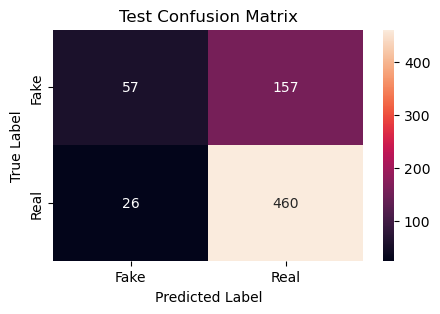

In [96]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [97]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = RandomForestClassifier()

param_grid = {'max_depth':[None,10,20], 'min_samples_leaf':[1,2,4], 'min_samples_split':[2,5,10], 'n_estimators':[10,50,100]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = RandomForestClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('RF Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

RF Classifier
Best hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Accuracy:  0.7385714285714285
Precision:  0.730593607305936
Recall:  0.9876543209876543
F1-score:  0.8398950131233596


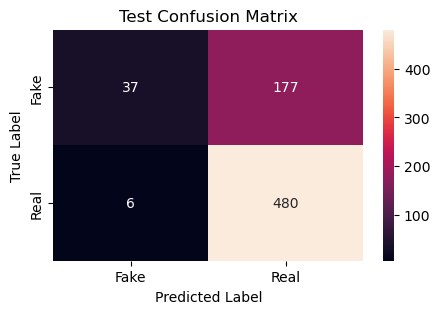

In [98]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [99]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = LogisticRegression()

param_grid = {'C':[0.001, 0.01, 0.1, 1, 10, 100], 'penalty':['l1', 'l2']}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = LogisticRegression(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('LR Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

LR Classifier
Best hyperparameters: {'C': 1, 'penalty': 'l2'}
Accuracy:  0.7542857142857143
Precision:  0.7565359477124183
Recall:  0.9526748971193416
F1-score:  0.8433515482695811


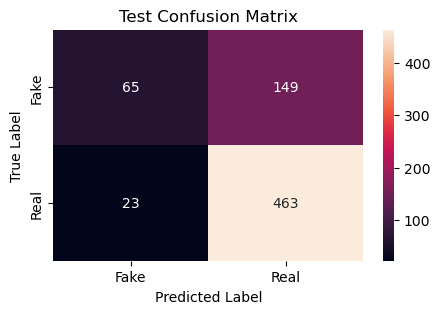

In [100]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [101]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = AdaBoostClassifier()

param_grid = {'n_estimators':[50,100,200], 'learning_rate':[0.01, 0.1, 1.0]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = AdaBoostClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('AdaB Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

AdaB Classifier
Best hyperparameters: {'learning_rate': 0.1, 'n_estimators': 200}
Accuracy:  0.7242857142857143
Precision:  0.7250384024577573
Recall:  0.9711934156378601
F1-score:  0.8302550571679859


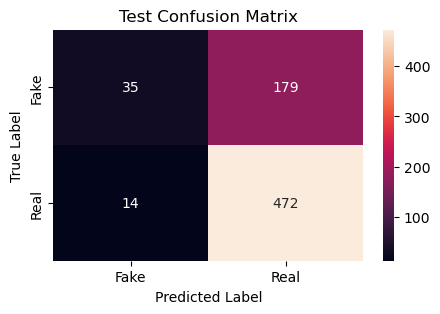

In [102]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [103]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = KNeighborsClassifier()

param_grid = {'n_neighbors':[3,5,7,9], 'weights':['uniform','distance'], 'p':[1,2]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = KNeighborsClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('KNN Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

KNN Classifier
Best hyperparameters: {'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
Accuracy:  0.8214285714285714
Precision:  0.9056179775280899
Recall:  0.8292181069958847
F1-score:  0.8657357679914072


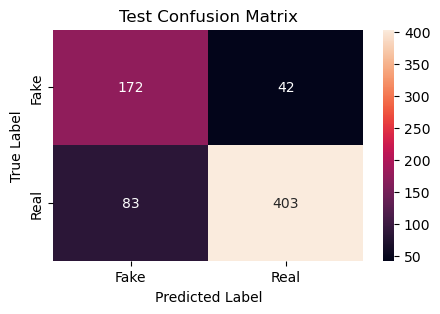

In [104]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [105]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = XGBClassifier()

param_grid = {'learning_rate':[0.01,0.1,0.2], 'n_estimators':[50,100,200], 'max_depth':[3,5,7], 'subsample':[0.8,1.0], 'colsample_bytree':[0.8,1.0], 'gamma':[0,0.1,0.2]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = XGBClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('XGB Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

XGB Classifier
Best hyperparameters: {'colsample_bytree': 0.8, 'gamma': 0.2, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}
Accuracy:  0.7442857142857143
Precision:  0.7394695787831513
Recall:  0.9753086419753086
F1-score:  0.8411712511091394


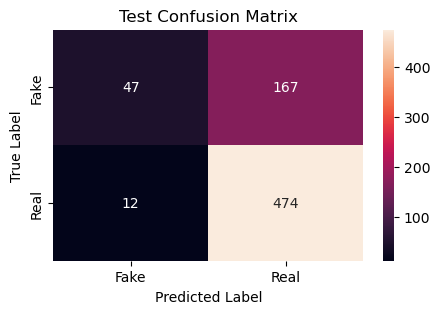

In [106]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [107]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = SVC()

param_grid = {'C':[0.1,1,10,100], 'kernel':['linear','rbf','poly','sigmoid']}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = SVC(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('SVM Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

SVM Classifier
Best hyperparameters: {'C': 1, 'kernel': 'rbf'}
Accuracy:  0.8628571428571429
Precision:  0.8482142857142857
Recall:  0.977366255144033
F1-score:  0.9082217973231358


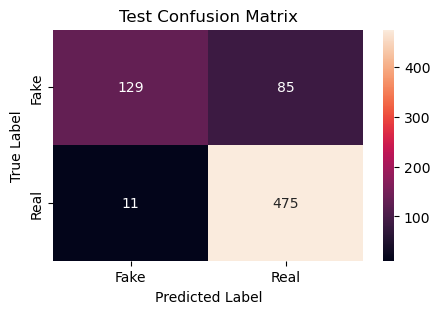

In [108]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [109]:
# DataFrame to csv

trainset_df.to_csv('trainset.tsv', sep='\t', index=False)
testset_df.to_csv('testset.tsv', sep='\t', index=False)